#  Chicago Crime Data Analytics


Environment Setup & Configuration

In [ ]:
import subprocess, sys
pkgs = [
    "sodapy", "folium", "geopandas", "contextily", "shapely",
    "scikit-learn", "xgboost", "lightgbm", "shap",
    "imbalanced-learn", "plotly", "kaleido", "tqdm", "pyarrow"
]
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=False)
print("Dependencies installed")


✅ Dependencies installed


In [2]:
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             ConfusionMatrixDisplay, f1_score, mean_absolute_error,
                             mean_squared_error, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import lightgbm as lgb
import shap
from imblearn.over_sampling import SMOTE
from tqdm.auto import tqdm
import plotly.io as pio



## Data Acquisition & Initial Exploration

In [ ]:
# load data


# from sodapy import Socrata
# def load_data(sample=SAMPLE_MODE, n=SAMPLE_ROWS, cache=CACHE_FILE):
#     if os.path.exists(cache):
#         print(f"Loading from cache: {cache}")
#         return pd.read_parquet(cache)

#     print("Fetching from Chicago Data Portal …")
#     client = Socrata("data.cityofchicago.org", None)  # anonymous – 1000 req/hr
#     limit  = n if sample else 8_500_000
#     rows   = client.get("ijzp-q8t2", limit=limit,
#                         order=":id",
#                         content_type="json")
#     df = pd.DataFrame.from_records(rows)
#     df.to_parquet(cache)
#     print(f"Fetched {len(df):,} rows → cached to {cache}")
#     return df

# df_raw = load_data()
# print(f"Shape: {df_raw.shape}")
# print(df_raw.dtypes.value_counts())
# df_raw.head(3)


#after loading the dataset once or downloading it manually, we can read it in chunks to save memory and then concatenate the chunks into a single DataFrame. This approach is especially useful for large datasets that may not fit into memory all at once.

chunks = []
for chunk in pd.read_csv("Crimes_-_2001_to_Present.csv", chunksize=50000):
    chunks.append(chunk)

df_raw = pd.concat(chunks, ignore_index=True)
print("Dataset loaded:", df_raw.shape)
print(f"Approx size in memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")



Dataset loaded: (7842937, 22)
Approx size in memory: 5602.3 MB


In [4]:
df_raw.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN


In [5]:
print(f"{'Total records':30s}: {len(df_raw):>12,}")
print(f"{'Unique crime types':30s}: {df_raw['Primary Type'].nunique():>12,}")
print(f"{'Date range':30s}: {df_raw['Year'].min()} – {df_raw['Year'].max()}")
print(f"{'Missing lat/lon (%)':30s}: {df_raw['Latitude'].isna().mean()*100:>11.1f}%")
print(f"{'Overall arrest rate (%)':30s}: {df_raw['Arrest'].map({'true':1,'false':0,True:1,False:0}).mean()*100:>11.1f}%")




Total records                 :    7,842,937
Unique crime types            :           36
Date range                    : 2001 – 2023
Missing lat/lon (%)           :         1.1%
Overall arrest rate (%)       :        26.0%


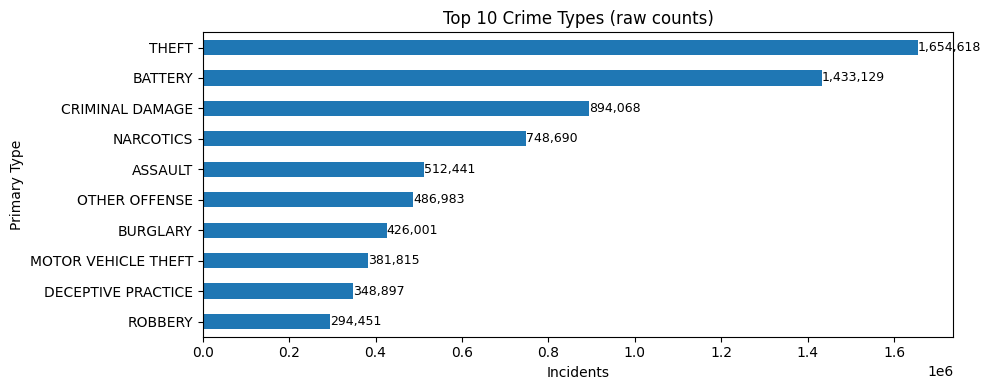

In [6]:
top10 = df_raw["Primary Type"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
top10.sort_values().plot.barh(ax=ax)
ax.set_title("Top 10 Crime Types (raw counts)")
ax.set_xlabel("Incidents")
for bar, val in zip(ax.patches, top10.sort_values().values):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### EDA


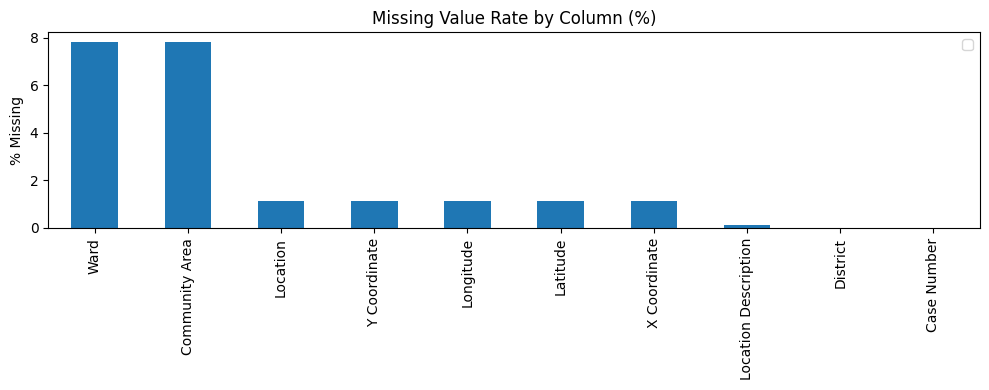

In [ ]:
# Missing value audit
missing = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 4))
missing.plot.bar(ax=ax)
ax.set_title("Missing Value Rate by Column (%)")
ax.set_ylabel("% Missing")
ax.legend()
plt.tight_layout(); plt.show()



In [8]:
print("\nColumns with >1% missing:")
print(missing[missing > 1].to_string())


Columns with >1% missing:
Ward              7.839525
Community Area    7.822019
Location          1.122309
Y Coordinate      1.122309
Longitude         1.122309
Latitude          1.122309
X Coordinate      1.122309


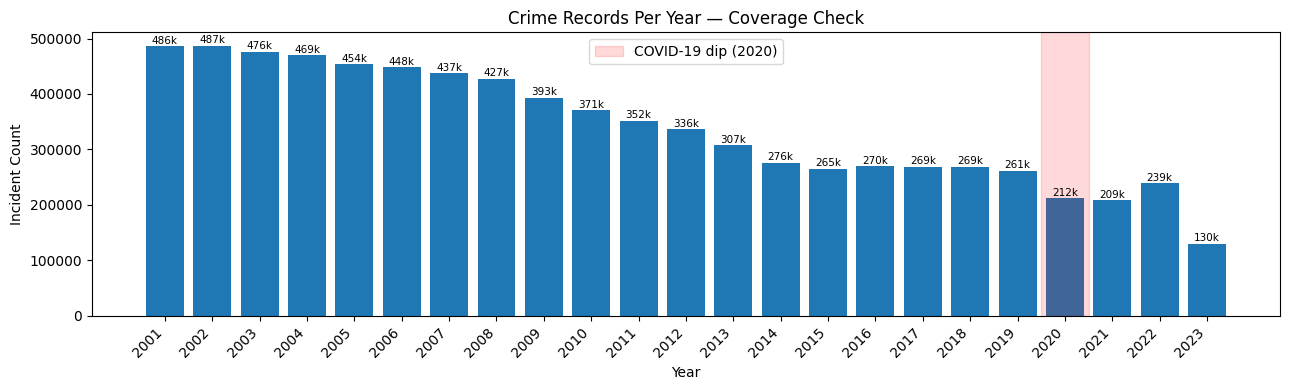

In [9]:
# Records per year
year_counts = df_raw["Year"].astype(str).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(year_counts.index, year_counts.values)
ax.set_title("Crime Records Per Year — Coverage Check")
ax.set_xlabel("Year"); ax.set_ylabel("Incident Count")

# Annotate bars
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val/1000:.0f}k", ha="center", va="bottom", fontsize=7.5)

# Highlight COVID dip
ax.axvspan(year_counts.index.tolist().index("2020") - 0.5,
           year_counts.index.tolist().index("2020") + 0.5,
           alpha=0.15, color="red", label="COVID-19 dip (2020)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


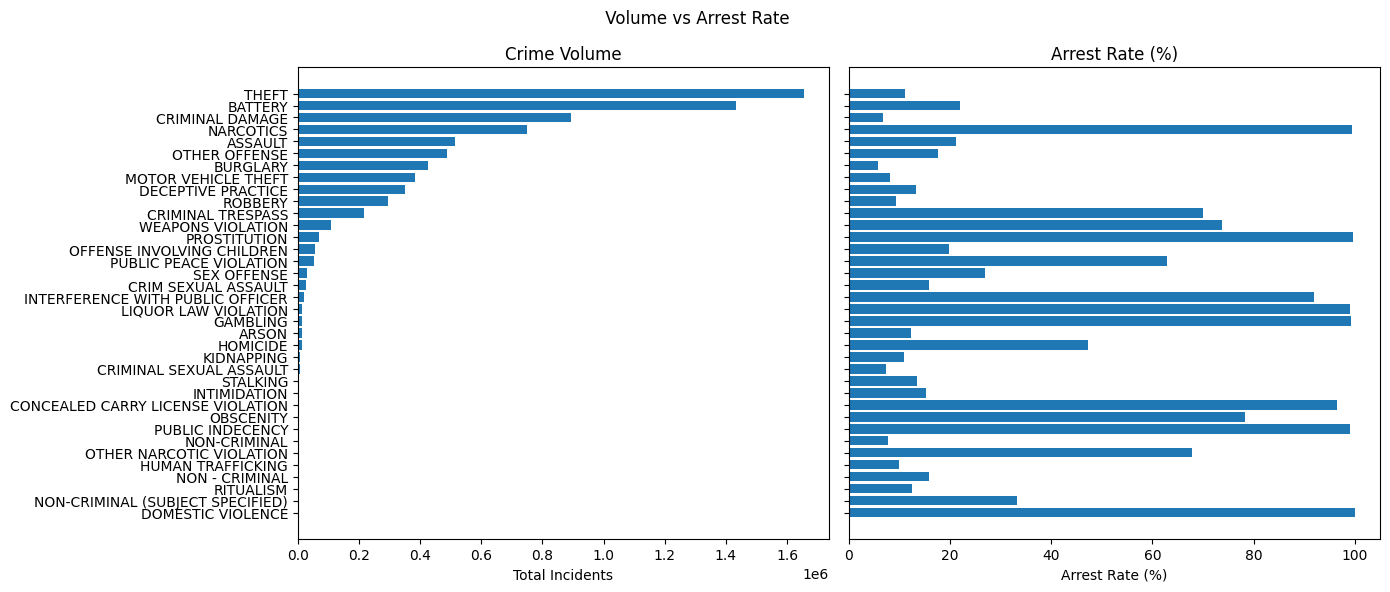

In [10]:
ct = df_raw.copy()
ct["arrest_flag"] = ct["Arrest"].map({"true":1,"false":0,True:1,False:0})

type_stats = (ct.groupby("Primary Type")
                .agg(count=("Case Number","count"),
                     arrest_rate=("arrest_flag","mean"))
                .sort_values("count", ascending=False)
                .reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Left plot: Crime count
ax1.barh(type_stats["Primary Type"], type_stats["count"])
ax1.set_title("Crime Volume")
ax1.set_xlabel("Total Incidents")
ax1.invert_yaxis()

# Right plot: Arrest rate
ax2.barh(type_stats["Primary Type"], type_stats["arrest_rate"] * 100)
ax2.set_title("Arrest Rate (%)")
ax2.set_xlabel("Arrest Rate (%)")

# Layout
plt.suptitle(" Volume vs Arrest Rate")
plt.tight_layout()
plt.show()

In [11]:
print(f"\nHighest arrest rate: {type_stats.nlargest(3,'arrest_rate')[['Primary Type','arrest_rate']].to_string(index=False)}")
print(f"Lowest  arrest rate: {type_stats.nsmallest(3,'arrest_rate')[['Primary Type','arrest_rate']].to_string(index=False)}")



Highest arrest rate:      Primary Type  arrest_rate
DOMESTIC VIOLENCE     1.000000
     PROSTITUTION     0.996093
        NARCOTICS     0.993868
Lowest  arrest rate:            Primary Type  arrest_rate
               BURGLARY     0.057145
        CRIMINAL DAMAGE     0.066856
CRIMINAL SEXUAL ASSAULT     0.073928


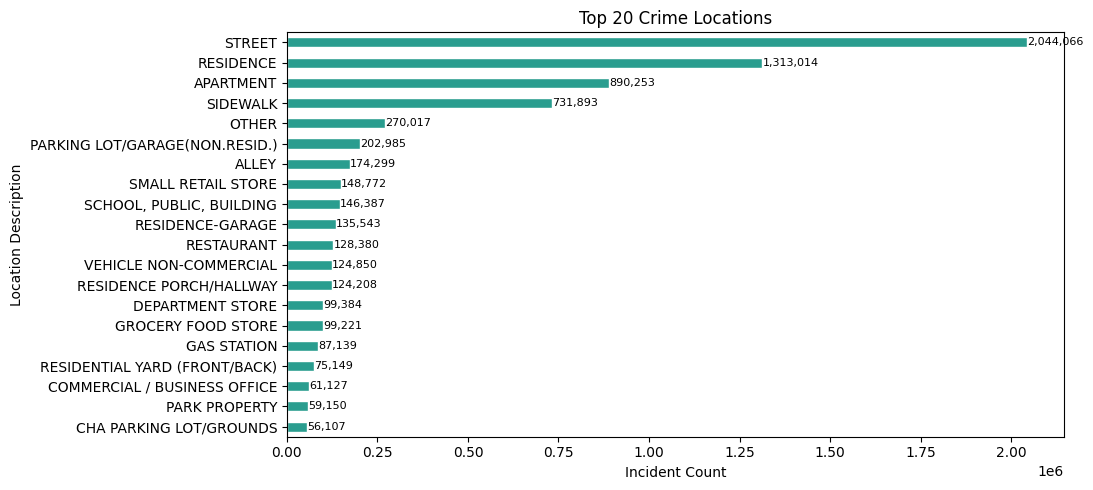

In [12]:
# Where do crimes happen? (Location Description) 
loc_counts = df_raw["Location Description"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(11, 5))
loc_counts.sort_values().plot.barh(ax=ax, color="#2A9D8F", edgecolor="white")
ax.set_title("Top 20 Crime Locations")
ax.set_xlabel("Incident Count")
for bar, val in zip(ax.patches, loc_counts.sort_values().values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()


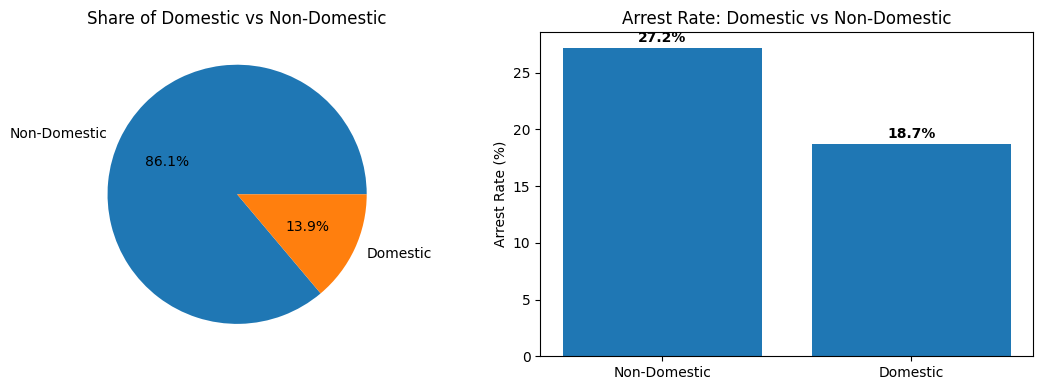

In [13]:
#  Domestic vs Non-Domestic crimes
dom = df_raw.copy()
dom["arrest_flag"] = dom["Arrest"].map({"true":1,"false":0,True:1,False:0})
dom["domestic_flag"] = dom["Domestic"].map({"true":True,"false":False,True:True,False:False})

dom_summary = dom.groupby("domestic_flag").agg(
    count=("Case Number","count"),
    arrest_rate=("arrest_flag","mean")
).reset_index()
dom_summary["label"] = dom_summary["domestic_flag"].map({True:"Domestic",False:"Non-Domestic"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(dom_summary["count"], labels=dom_summary["label"],
            autopct="%1.1f%%")
axes[0].set_title("Share of Domestic vs Non-Domestic")

axes[1].bar(dom_summary["label"], dom_summary["arrest_rate"]*100)
axes[1].set_title("Arrest Rate: Domestic vs Non-Domestic")
axes[1].set_ylabel("Arrest Rate (%)")
for bar, val in zip(axes[1].patches, dom_summary["arrest_rate"]*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout(); plt.show()


In [14]:
# District-level breakdown
dist = df_raw.copy()
dist["arrest_flag"] = dist["Arrest"].map({"true":1,"false":0,True:1,False:0})

dist_stats = (dist.groupby("District")
              .agg(count=("Case Number","count"),
                   arrest_rate=("arrest_flag","mean"))
              .reset_index()
              .sort_values("count", ascending=False))

fig = make_subplots(rows=1, cols=2,
    subplot_titles=["Total Incidents by District","Arrest Rate by District"])

fig.add_trace(go.Bar(x=dist_stats["District"], y=dist_stats["count"]), row=1, col=1)
fig.add_trace(go.Bar(x=dist_stats["District"], y=dist_stats["arrest_rate"]*100), row=1, col=2)

fig.update_layout(height=420, template="plotly_white",
    title=" District-Level Crime & Arrest Overview", showlegend=False)
fig.show()


## Data Cleaning & Feature Engineering

In [15]:
#  Type coercion & date parsing 
df = df_raw.copy()

In [16]:
# Numeric coercion
for col in ["Latitude","Longitude"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df["Date"] = pd.to_datetime(df["Date"],format="%m/%d/%Y %I:%M:%S %p",errors="coerce")

In [19]:
# Boolean flags
for col in ["Arrest","Domestic"]:
    if df[col].dtype == object:
        df[col] = df[col].str.lower().map({"true":True,"false":False,True:True,False:False})

In [20]:
df["Year"] = df["Year"].astype(int, errors="ignore")
print(" Type coercion done")
print(df[["Date","Latitude","Longitude","Arrest","Domestic"]].dtypes)


 Type coercion done
Date         datetime64[ns]
Latitude            float64
Longitude           float64
Arrest                 bool
Domestic               bool
dtype: object


In [21]:
# Deduplication on Case Number 
before = len(df)
df = df.sort_values("Date").drop_duplicates(subset="Case Number", keep="last")
print(f"Removed {before - len(df):,} duplicate case numbers  →  {len(df):,} rows remain")


Removed 549 duplicate case numbers  →  7,842,388 rows remain


In [ ]:
CHICAGO_BBOX  = dict(lat_min=41.6, lat_max=42.1, lon_min=-87.9, lon_max=-87.5)

In [ ]:
# Missing values & coordinate bounding box 
# Fill location description
df["Location Description"] = df["Location Description"].fillna("Unknown")

# Spatial subset (keep originals for temporal analysis)
valid_coords = (
    df["Latitude"].between(CHICAGO_BBOX["lat_min"], CHICAGO_BBOX["lat_max"]) &
    df["Longitude"].between(CHICAGO_BBOX["lon_min"], CHICAGO_BBOX["lon_max"])
)
df_spatial = df[valid_coords].copy()
df_temporal = df.copy()       

print(f"Spatial   df : {len(df_spatial):,} rows  ({valid_coords.mean()*100:.1f}% of total)")
print(f"Temporal  df : {len(df_temporal):,} rows")


Spatial   df : 7,728,273 rows  (98.5% of total)
Temporal  df : 7,842,388 rows


In [74]:
#  Feature engineering

def engineer_features(df):
    d = df.copy()

    # Temporal 
    d["hour"]       = d["Date"].dt.hour
    d["dow"]        = d["Date"].dt.dayofweek          # Mon=0
    d["month"]      = d["Date"].dt.month
    d["week"]       = d["Date"].dt.isocalendar().week.astype(int)
    d["is_weekend"] = d["dow"].ge(5).astype(int)
    d["season"]     = d["month"].map({
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Fall",10:"Fall",11:"Fall"
    })
    d["time_bucket"] = pd.cut(d["hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["Night(0-5)","Morning(6-11)","Afternoon(12-17)","Evening(18-23)"]
    )

    # Broad crime super-category 
    violent  = {"HOMICIDE","CRIM SEXUAL ASSAULT","ROBBERY","ASSAULT","BATTERY",
                "KIDNAPPING","HUMAN TRAFFICKING","INTIMIDATION","STALKING"}
    property_ = {"BURGLARY","THEFT","MOTOR VEHICLE THEFT","ARSON","CRIMINAL DAMAGE",
                 "CRIMINAL TRESPASS"}
    drugs     = {"NARCOTICS","OTHER NARCOTIC VIOLATION"}
    quality   = {"PROSTITUTION","GAMBLING","LIQUOR LAW VIOLATION",
                 "PUBLIC PEACE VIOLATION","OBSCENITY"}

    def categorize(t):
        if t in violent:   return "Violent"
        if t in property_: return "Property"
        if t in drugs:     return "Drugs"
        if t in quality:   return "Quality of Life"
        return "Other"

    d["crime_category"] = d["Primary Type"].apply(categorize)

    # Location bucket 
    loc_map = {
        "RESIDENCE":"Residential","APARTMENT":"Residential","HOUSE":"Residential",
        "STREET":"Street","ALLEY":"Street","SIDEWALK":"Street",
        "RETAIL STORE":"Commercial","RESTAURANT":"Commercial",
        "GROCERY FOOD STORE":"Commercial","GAS STATION DRIVE/THROUGH":"Commercial",
        "CTA BUS":"Transit","CTA TRAIN":"Transit","CTA PLATFORM":"Transit",
        "SCHOOL, PUBLIC, BUILDING":"School","SCHOOL, PRIVATE, BUILDING":"School",
        "PARK PROPERTY":"Park","PARKING LOT/GARAGE(NON.RESID.)":"Parking",
        "BAR OR TAVERN":"Entertainment","ATHLETIC CLUB":"Entertainment",
        "BANK":"Financial","CURRENCY EXCHANGE":"Financial",
    }
    d["loc_bucket"] = d["Location Description"].map(loc_map).fillna("Other")

    #  Spatial grid (0.01° ≈ 0.9km)
    if "Latitude" in d.columns:
        d["grid_lat"] = (d["Latitude"]  / 0.01).apply(lambda x: int(x) if pd.notna(x) else np.nan)
        d["grid_lon"] = (d["Longitude"] / 0.01).apply(lambda x: int(x) if pd.notna(x) else np.nan)
        d["grid_id"]  = d["grid_lat"].astype(str) + "_" + d["grid_lon"].astype(str)

    return d

df_temporal = engineer_features(df_temporal)
df_spatial  = engineer_features(df_spatial)

print("✅ Feature engineering complete")
print("New columns:", [c for c in df_temporal.columns if c not in df.columns])


✅ Feature engineering complete
New columns: ['hour', 'dow', 'month', 'week', 'is_weekend', 'season', 'time_bucket', 'crime_category', 'loc_bucket', 'grid_lat', 'grid_lon', 'grid_id']


In [ ]:
# Hour-of-day distribution by crime super-category
try:
    hour_cat = df_temporal.groupby(["hour","crime_category"]).size().reset_index(name="count")

    fig = px.line(hour_cat, x="hour", y="count", color="crime_category",
                  markers=True, title="Crime Volume by Hour & Category",
                  labels={"hour":"Hour of Day","count":"Incidents","crime_category":"Category"},
                  template="plotly_white")
    fig.update_layout(height=420, hovermode="x unified")
    fig.show()
except NameError:
    print("Run Phase 2 feature engineering first to get df_temporal")


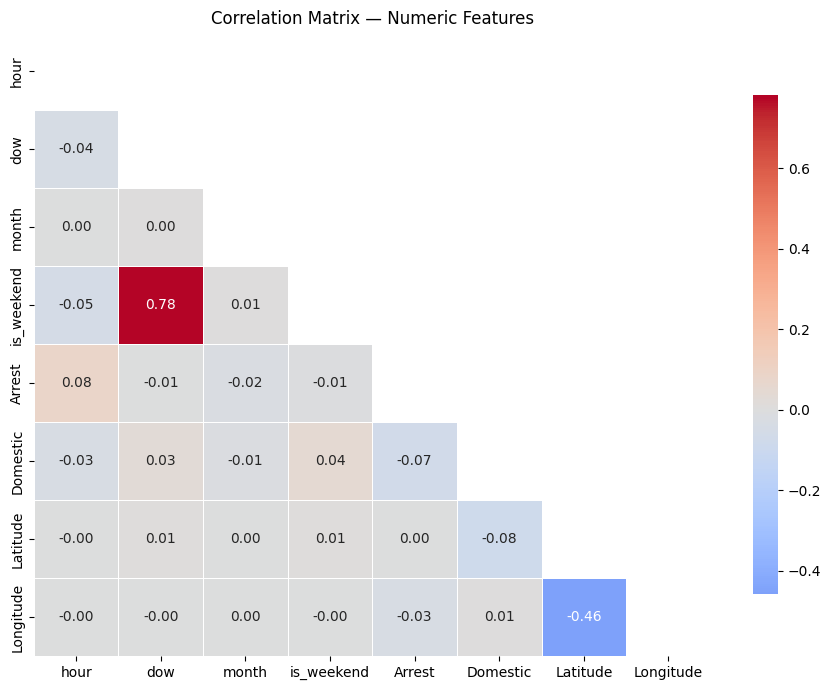

In [29]:
# Correlation heatmap (numeric features)
try:
    num_cols = ["hour","dow","month","is_weekend","Arrest","Domestic",
                "Latitude","Longitude"]
    corr_df = df_temporal[num_cols].copy()
    corr_df["Arrest"]   = corr_df["Arrest"].astype(float)
    corr_df["Domestic"] = corr_df["Domestic"].astype(float)
    corr = corr_df.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, ax=ax,
                cbar_kws={"shrink":.8})
    ax.set_title("Correlation Matrix — Numeric Features")
    plt.tight_layout(); plt.show()
except NameError:
    print(" Run Phase 2 first to get df_temporal")


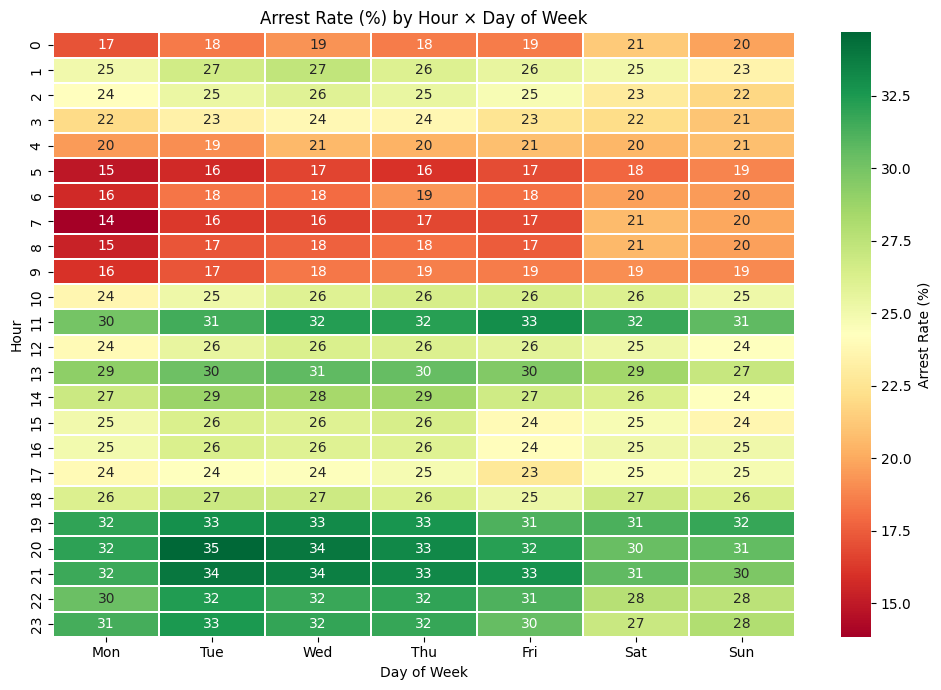

In [30]:
# Arrest rate heatmap: Hour × Day 
try:
    arr_heat = (df_temporal.groupby(["hour","dow"])["Arrest"]
                .mean().unstack() * 100)
    arr_heat.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(arr_heat, ax=ax, cmap="RdYlGn", annot=True, fmt=".0f",
                linewidths=0.3, cbar_kws={"label":"Arrest Rate (%)"})
    ax.set_title("Arrest Rate (%) by Hour × Day of Week")
    ax.set_xlabel("Day of Week"); ax.set_ylabel("Hour")
    plt.tight_layout(); plt.show()
except NameError:
    print("Run Phase 2 first")


In [32]:
# Top location types per crime category
try:
    loc_cat = (df_temporal.groupby(["crime_category","loc_bucket"])
               .size().reset_index(name="count"))
    loc_cat["pct"] = loc_cat.groupby("crime_category")["count"].transform(lambda x: x/x.sum()*100)

    fig = px.bar(loc_cat.sort_values("count", ascending=False),
                 x="loc_bucket", y="pct", color="crime_category",
                 barmode="group", template="plotly_white",
                 title="Where Each Crime Category Happens (% within category)",
                 labels={"loc_bucket":"Location","pct":"% of Category","crime_category":"Category"}, height=420)
    fig.update_xaxes(tickangle=30)
    fig.show()
except NameError:
    print("Run Phase 2 first")


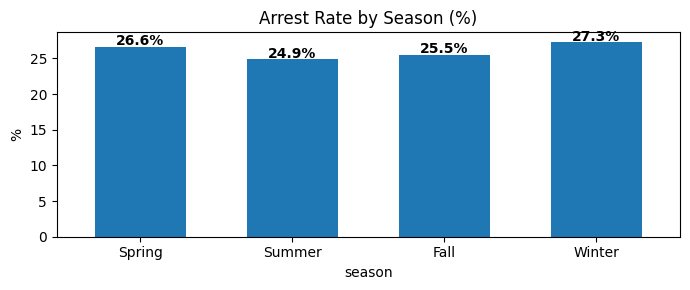

In [34]:
# Seasonal patterns 
try:
    season_order = ["Spring","Summer","Fall","Winter"]
    season_data  = (df_temporal.groupby(["season","crime_category"])
                    .size().reset_index(name="count"))

    fig = px.bar(season_data, x="season", y="count", color="crime_category",
                 barmode="stack", category_orders={"season": season_order},
                 template="plotly_white", height=420,
                 title="🌦️ Crime Volume by Season & Category",
                 labels={"season":"Season","count":"Incidents","crime_category":"Category"})
    fig.show()

    # Arrest rate by season
    season_arr = (df_temporal.groupby("season")["Arrest"]
                  .mean().reindex(season_order) * 100)
    fig2, ax = plt.subplots(figsize=(7, 3))
    season_arr.plot.bar(ax=ax,width=0.6)
    ax.set_title("Arrest Rate by Season (%)"); ax.set_ylabel("%")
    ax.set_xticklabels(season_order, rotation=0)
    for bar, val in zip(ax.patches, season_arr):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout(); plt.show()
except NameError:
    print("Run Phase 2 first")


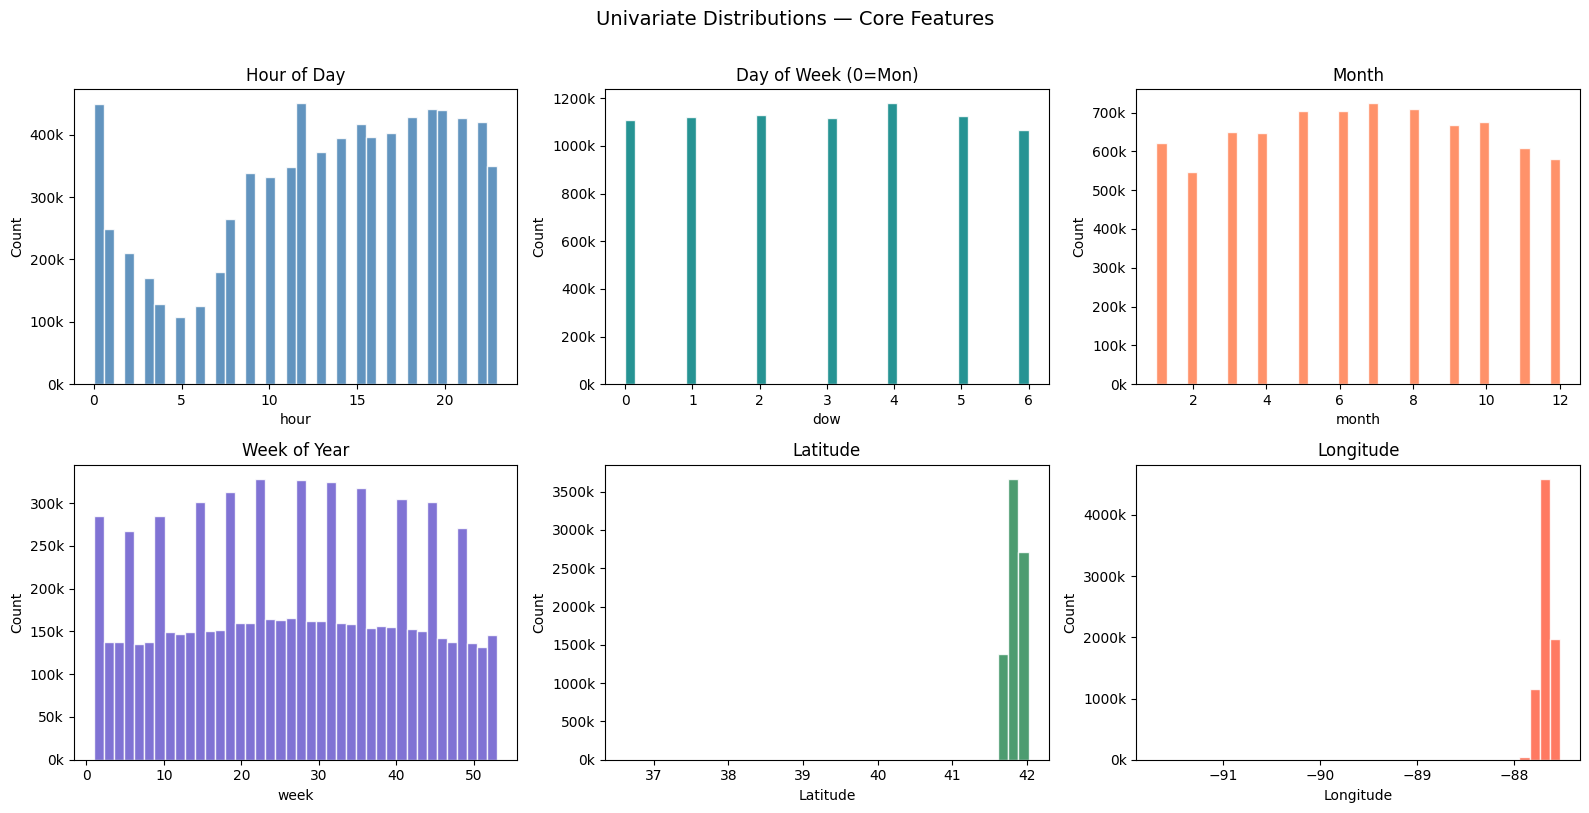

In [35]:
#Univariate distributions — key numeric features
try:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    plots = [
        ("hour",        "Hour of Day",       "steelblue"),
        ("dow",         "Day of Week (0=Mon)","teal"),
        ("month",       "Month",             "coral"),
        ("week",        "Week of Year",      "slateblue"),
        ("Latitude",    "Latitude",          "seagreen"),
        ("Longitude",   "Longitude",         "tomato"),
    ]

    for ax, (col, title, color) in zip(axes, plots):
        data = df_temporal[col].dropna()
        ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.85)
        ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Count")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))

    plt.suptitle("Univariate Distributions — Core Features", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()
except NameError:
    print(" Run Phase 2 first")


##  Temporal Analysis

In [36]:
# Year-over-year trend
yearly = (df_temporal.groupby(["Year","crime_category"])
          .size().reset_index(name="count"))
yearly_total = yearly.groupby("Year")["count"].sum().reset_index()

fig = make_subplots(rows=1, cols=2,
    subplot_titles=["Total Crimes Per Year", "By Crime Category"])

fig.add_trace(go.Scatter(x=yearly_total["Year"], y=yearly_total["count"],
    mode="lines+markers", line=dict( width=3),
    marker=dict(size=7), name="Total"), row=1, col=1)

for cat, grp in yearly.groupby("crime_category"):
    fig.add_trace(go.Scatter(x=grp["Year"], y=grp["count"],
        mode="lines+markers", name=cat, marker=dict(size=5)), row=1, col=2)

fig.update_layout(height=400, title_text="Crime Trend Over Years",
    hovermode="x unified", template="plotly_white")
fig.show()


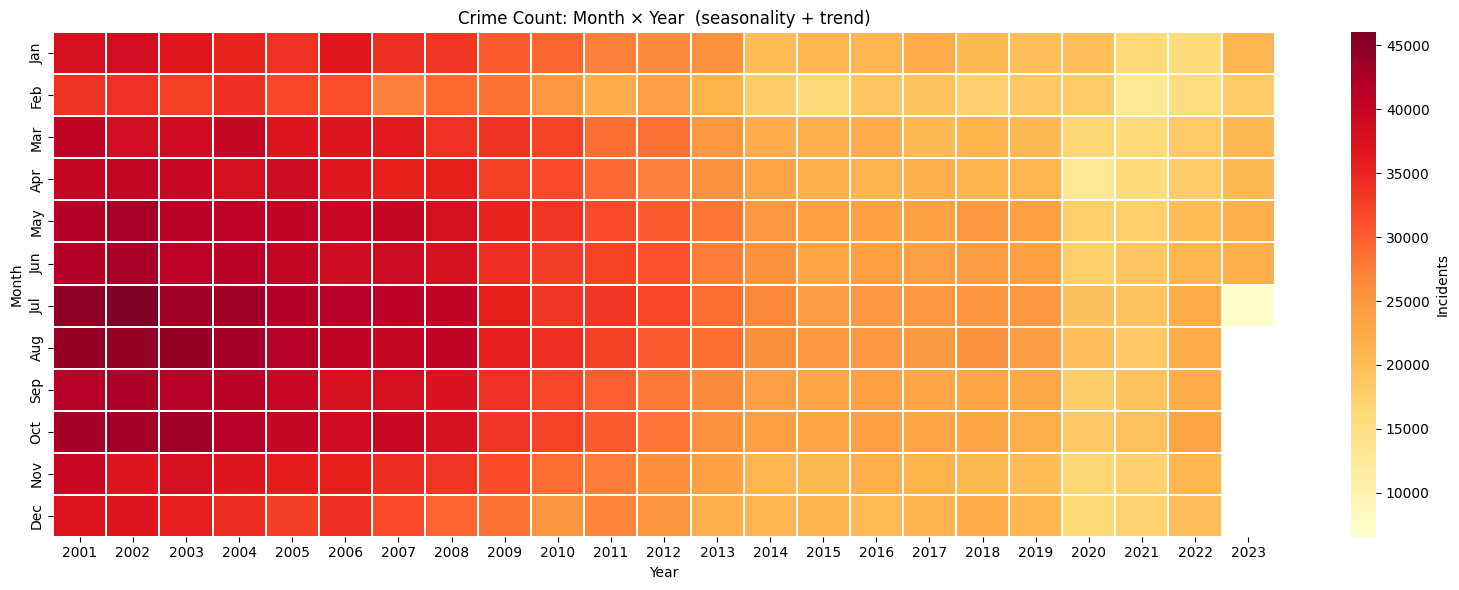

In [38]:
heat_data = (df_temporal.groupby(["Year","month"])
             .size().reset_index(name="count")
             .pivot(index="month", columns="Year", values="count"))

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heat_data, ax=ax, cmap="YlOrRd", linewidths=.3,
            cbar_kws={"label": "Incidents"},
            yticklabels=["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Crime Count: Month × Year  (seasonality + trend)")
ax.set_xlabel("Year"); ax.set_ylabel("Month")
plt.tight_layout(); plt.show()

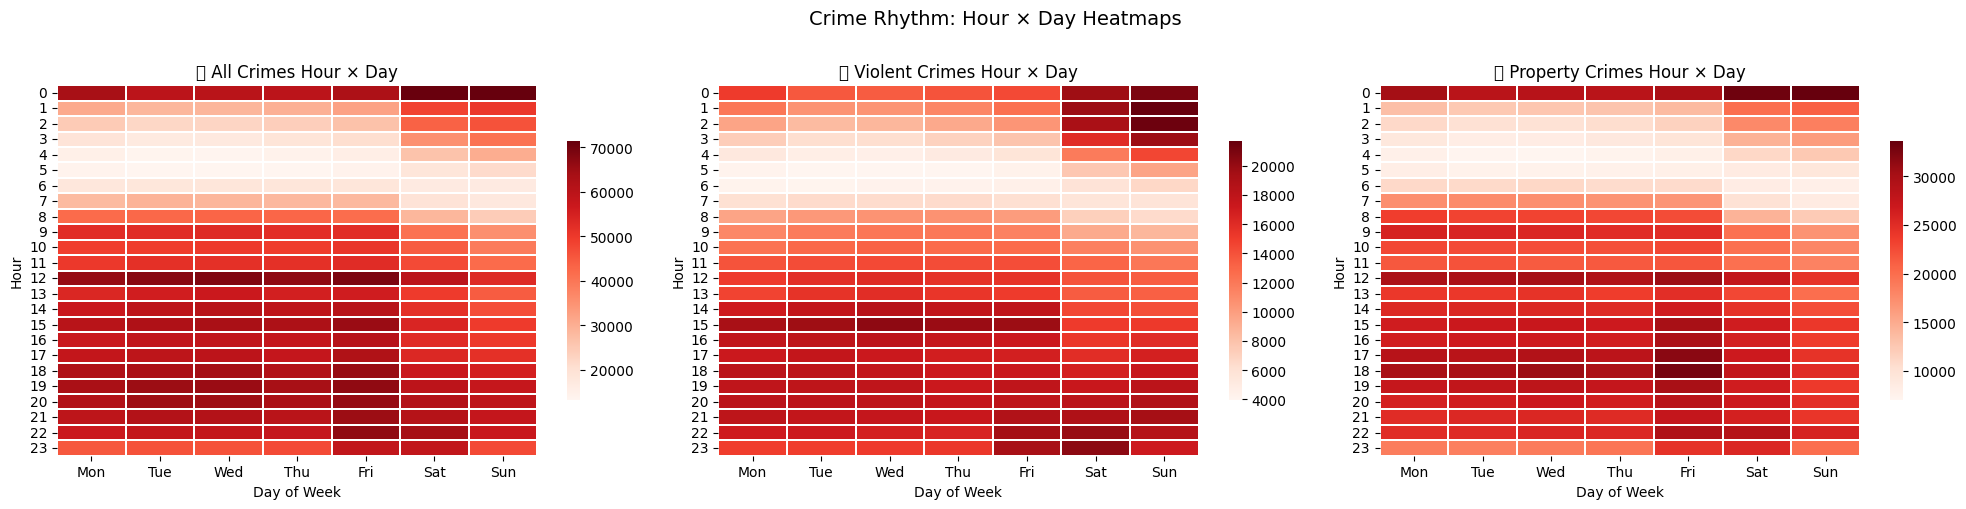

In [39]:
#  Hour × Day-of-Week heatmap (overall + by category)
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (title, subset) in zip(axes, [
    ("All Crimes",          df_temporal),
    ("Violent Crimes",      df_temporal[df_temporal.crime_category=="Violent"]),
    ("Property Crimes",     df_temporal[df_temporal.crime_category=="Property"]),
]):
    piv = subset.groupby(["hour","dow"]).size().unstack(fill_value=0)
    piv.columns = [dow_labels[c] for c in piv.columns]
    sns.heatmap(piv, ax=ax, cmap="Reds", linewidths=.2,
                cbar_kws={"shrink":.7})
    ax.set_title(f"⏰ {title} Hour × Day", fontsize=12)
    ax.set_xlabel("Day of Week"); ax.set_ylabel("Hour")

plt.suptitle("Crime Rhythm: Hour × Day Heatmaps", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


In [42]:
#Arrest rate trend over years 
arr_trend = (df_temporal.groupby("Year")["Arrest"]
             .agg(["mean","count"])
             .reset_index()
             .rename(columns={"mean":"arrest_rate"}))

fig = go.Figure()
fig.add_trace(go.Bar(x=arr_trend["Year"], y=arr_trend["count"],
    name="Total Incidents", marker_color="lightblue", yaxis="y2", opacity=0.5))
fig.add_trace(go.Scatter(x=arr_trend["Year"], y=arr_trend["arrest_rate"]*100,
    mode="lines+markers", name="Arrest Rate (%)",
    line=dict( width=3), marker=dict(size=8)))

fig.update_layout(
    title=" Arrest Rate vs Incident Volume Over Time",
    yaxis=dict(title="Arrest Rate (%)", range=[0, 50]),
    yaxis2=dict(title="Total Incidents", overlaying="y", side="right"),
    hovermode="x unified", template="plotly_white", height=420
)
fig.show()




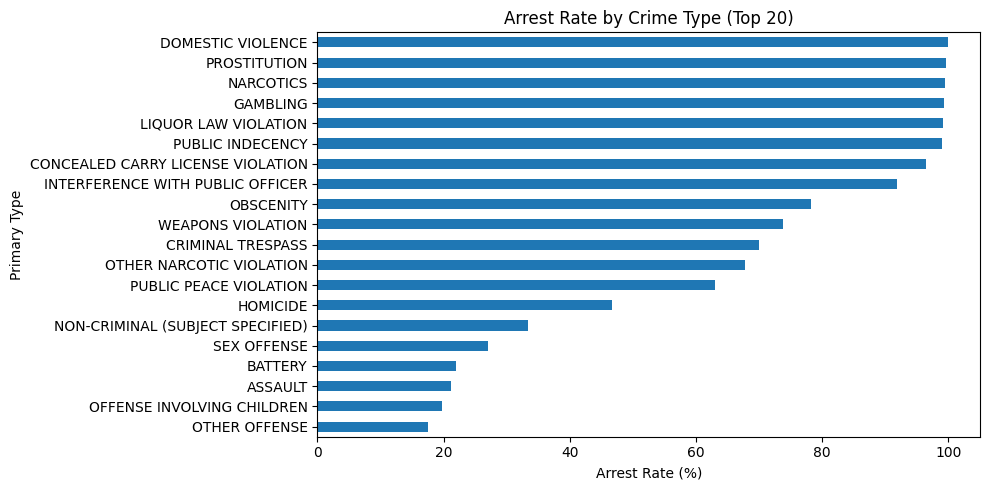

In [41]:
# By crime type
arr_by_type = (df_temporal.groupby("Primary Type")["Arrest"]
               .mean().sort_values(ascending=False).head(20) * 100)
fig2, ax = plt.subplots(figsize=(10, 5))
arr_by_type.sort_values().plot.barh(ax=ax)
ax.set_title("Arrest Rate by Crime Type (Top 20)")
ax.set_xlabel("Arrest Rate (%)")
plt.tight_layout(); plt.show()

## Spatial Analysis

In [43]:
RANDOM_STATE = 42

In [57]:
import folium
from folium.plugins import HeatMap, Fullscreen, MousePosition
from IPython.display import HTML

# Sample data
map_sample = df_spatial[["Latitude","Longitude"]].dropna().sample(
    min(80000, len(df_spatial)), random_state=RANDOM_STATE
)

# Create map
m = folium.Map(
    location=[41.85, -87.65],
    zoom_start=11,
    tiles="CartoDB positron"   # cleaner look
)

# Heatmap layer
HeatMap(
    data=map_sample.values.tolist(),
    radius=10,
    blur=18,
    max_zoom=13,
    min_opacity=0.3,
    gradient={
        0.1: "navy",
        0.3: "blue",
        0.5: "lime",
        0.7: "yellow",
        0.9: "orange",
        1.0: "red"
    }
).add_to(m)

# Add extras (visual polish)
Fullscreen().add_to(m)
MousePosition().add_to(m)
folium.LayerControl().add_to(m)

# FORCE RENDER IN VS CODE
from IPython.display import display, HTML

html_map = m.get_root().render()

display(HTML(f"""
<iframe srcdoc='{html_map}' width="100%" height="600" style="border:none;"></iframe>
"""))

In [ ]:
# Choropleth by Community Area 
comm_counts = (df_spatial.groupby("Community Area")
               .agg(total=("Case Number","count"),
                    arrest_rate=("Arrest","mean"),
                    violent_share=("crime_category",
                        lambda x: (x=="Violent").mean()))
               .reset_index())

# Interactive plotly choropleth (uses community area number as proxy)
fig = make_subplots(rows=1, cols=3,
    subplot_titles=["Total Crimes","Arrest Rate","Violent Crime Share"],
    specs=[[{"type":"bar"},{"type":"bar"},{"type":"bar"}]])

for col_idx, (col, label, color) in enumerate([
    ("total",          "Incidents",      "reds"),
    ("arrest_rate",    "Arrest Rate",    "blues"),
    ("violent_share",  "Violent Share",  "oranges"),
], start=1):
    top = comm_counts.nlargest(25, col)
    fig.add_trace(go.Bar(
        x=top["Community Area"].astype(str),
        y=top[col], name=label,
        marker_color=top[col], showlegend=False
    ), row=1, col=col_idx)

fig.update_layout(height=400, title="Community Area Profiles (Top 25)",
                  template="plotly_white")
fig.show()


In [ ]:
def make_category_heatmap(category, color_gradient, title):
    subset = (df_spatial[df_spatial.crime_category == category]
              [["Latitude", "Longitude"]]
              .dropna())

    subset = subset.sample(min(50000, len(subset)), random_state=RANDOM_STATE)

    m2 = folium.Map(
        location=[41.85, -87.65],
        zoom_start=11,
        tiles=None  
    )

    folium.TileLayer("OpenStreetMap").add_to(m2)

    HeatMap(
        subset.values.tolist(),
        radius=9,
        blur=14,
        gradient=color_gradient
    ).add_to(m2)

    html_map = m2.get_root().render()

    display(HTML(f"""
    <h3 style="text-align:center;">{title}</h3>
    <iframe srcdoc='{html_map}' width="100%" height="400" style="border:none;"></iframe>
    """))

In [ ]:
# Violent crime heatmap
make_category_heatmap(
    "Violent",
    {0.4: "blue", 0.6: "red", 1: "darkred"},
    "Violent Crime Hotspots"
)

In [ ]:
#Property Crime Hotspots
make_category_heatmap(
    "Property",
    {0.4: "green", 0.6: "yellow", 1: "orange"},
    "Property Crime Hotspots"
)

In [73]:
df_spatial.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7728273 entries, 44460 to 20909
Data columns (total 31 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  object        
 5   Primary Type          object        
 6   Description           object        
 7   Location Description  object        
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              float64       
 12  Ward                  float64       
 13  Community Area        float64       
 14  FBI Code              object        
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int64         
 18  Updated On            object        
 19  Lat

## Clustering / Hotspot Detection

In [75]:
# Build grid-cell feature vectors for clustering & prediction
grid = (df_spatial.groupby("grid_id").agg(
    lat         = ("Latitude",  "mean"),
    lon         = ("Longitude", "mean"),
    total       = ("Case Number","count"),
    violent_frac= ("crime_category", lambda x: (x=="Violent").mean()),
    property_frac=("crime_category", lambda x: (x=="Property").mean()),
    arrest_rate = ("Arrest",    "mean"),
    night_frac  = ("time_bucket",lambda x: (x=="Night(0-5)").mean()),
    eve_frac    = ("time_bucket",lambda x: (x=="Evening(18-23)").mean()),
    weekend_frac= ("is_weekend","mean"),
).reset_index().dropna())

In [76]:
# Filter low-sample cells (noise)
grid = grid[grid["total"] >= 10].copy()
print(f"Grid cells: {len(grid):,}")


Grid cells: 699


In [77]:
# Normalize
from sklearn.preprocessing import MinMaxScaler
feature_cols = ["total","violent_frac","property_frac","arrest_rate",
                "night_frac","eve_frac","weekend_frac"]
scaler = MinMaxScaler()
X_grid = scaler.fit_transform(grid[feature_cols])

grid[feature_cols] = X_grid
print(grid[feature_cols].describe().round(3))


         total  violent_frac  property_frac  arrest_rate  night_frac  \
count  699.000       699.000        699.000      699.000     699.000   
mean     0.127         0.402          0.595        0.296       0.249   
std      0.127         0.135          0.137        0.129       0.080   
min      0.000         0.000          0.000        0.000       0.000   
25%      0.026         0.306          0.503        0.201       0.213   
50%      0.097         0.408          0.603        0.278       0.245   
75%      0.182         0.503          0.681        0.363       0.278   
max      1.000         1.000          1.000        1.000       1.000   

       eve_frac  weekend_frac  
count   699.000       699.000  
mean      0.460         0.393  
std       0.090         0.080  
min       0.000         0.000  
25%       0.438         0.366  
50%       0.475         0.388  
75%       0.508         0.415  
max       1.000         1.000  


In [93]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

coords_rad = np.radians(grid[["lat", "lon"]].values)

eps_km  = 1.5
eps_rad = eps_km / 6371.0

db = DBSCAN(
    eps=eps_rad,
    min_samples=8,
    algorithm="ball_tree",
    metric="haversine"
).fit(coords_rad)

grid["dbscan_label"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()
print(f"DBSCAN → {n_clusters} hotspot clusters | {n_noise:,} noise cells")


DBSCAN → 4 hotspot clusters | 32 noise cells


K-Means tuning: 100%|██████████| 9/9 [00:00<00:00, 13.46it/s]


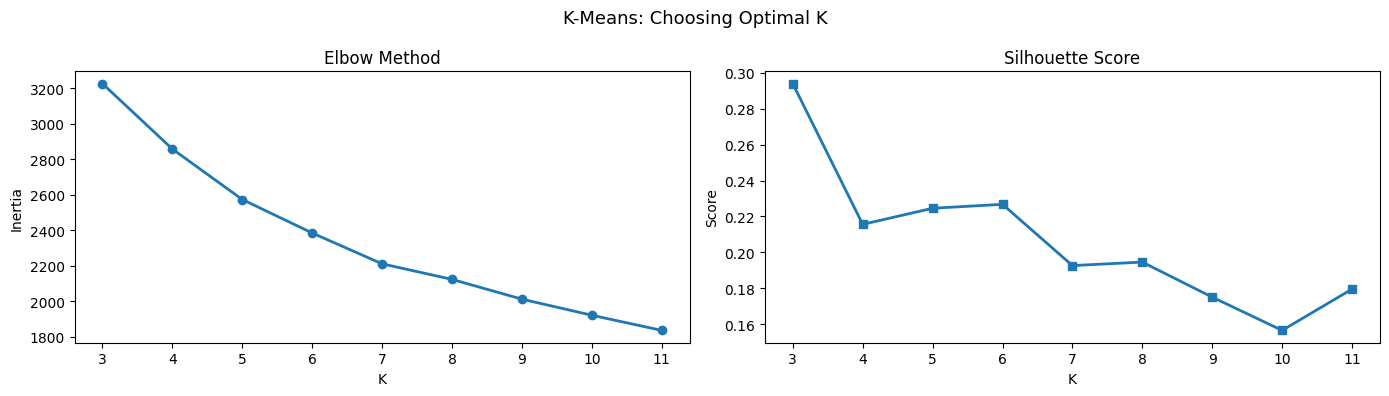

Best K by silhouette: 3


In [ ]:

# K-Means: elbow + silhouette 
inertia, silhouette = [], []
K_range = range(3, 12)

for k in tqdm(K_range, desc="K-Means tuning"):
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_grid)
    inertia.append(km.inertia_)
    silhouette.append(
        silhouette_score(X_grid, labels, sample_size=5000, random_state=RANDOM_STATE)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(K_range, inertia,    "o-", lw=2)
ax1.set_title("Elbow Method");   ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax2.plot(K_range, silhouette, "s-", lw=2)
ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("Score")
plt.suptitle("K-Means: Choosing Optimal K", fontsize=13)
plt.tight_layout(); plt.show()

BEST_K = K_range[int(np.argmax(silhouette))]
print(f"Best K by silhouette: {BEST_K}")


In [ ]:
#  Fit best K-Means
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=15)
grid["kmeans_label"] = km_final.fit_predict(X_grid)


In [ ]:
#  Profile clusters
profile = grid.groupby("kmeans_label")[feature_cols].mean().round(3)
print("\nCluster Profiles (normalized means):")
print(profile.to_string())



Cluster Profiles (normalized means):
              total  violent_frac  property_frac  arrest_rate  night_frac  eve_frac  weekend_frac
kmeans_label                                                                                     
0             0.070         0.395          0.571        0.353       0.493     0.277         0.564
1             0.066         0.326          0.680        0.226       0.248     0.453         0.387
2             0.221         0.514          0.474        0.393       0.231     0.487         0.388


In [ ]:
# Data-driven thresholds
p_violent  = profile["violent_frac"].quantile(0.60)  
p_property = profile["property_frac"].quantile(0.60)
p_night    = profile["night_frac"].quantile(0.60)
p_arrest   = profile["arrest_rate"].quantile(0.60)
p_total    = profile["total"].quantile(0.60)

print(f"\nDynamic thresholds → violent:{p_violent:.3f}  property:{p_property:.3f}  "
      f"night:{p_night:.3f}  arrest:{p_arrest:.3f}  total:{p_total:.3f}")

def name_cluster(row):
    """
    Classify using RELATIVE thresholds derived from cluster-mean distribution.
    Priority order matters — most dangerous label wins first.
    """
    if row["violent_frac"]  >= p_violent:   return "Nighttime Violent Hotspot"
    if row["property_frac"] >= p_property:  return "Daytime Property Crime Zone"
    if row["night_frac"]    >= p_night:     return "Night Activity Zone"
    if row["arrest_rate"]   >= p_arrest:    return "High Clearance Area"
    if row["total"]         >= p_total:     return "High Volume Commercial"
    return "Low-Crime Residential"

profile["name"] = profile.apply(name_cluster, axis=1)
cluster_names   = profile["name"].to_dict()
grid["cluster_name"] = grid["kmeans_label"].map(cluster_names)

print("\nCluster Names:")
for k, v in cluster_names.items():
    count = (grid["kmeans_label"] == k).sum()
    print(f"  Cluster {k}: {v}  ({count:,} cells)")
assigned = set(grid["cluster_name"].unique())
print(f"\nUnique cluster names in grid: {assigned}")
color_map = {
    "Nighttime Violent Hotspot":   "#E63946",
    "Daytime Property Crime Zone": "#F4A261",
    "Night Activity Zone":         "#6A4C93",
    "High Clearance Area":         "#2A9D8F",
    "High Volume Commercial":      "#E9C46A",
    "Low-Crime Residential":       "#ADB5BD",
}

# Sanity check — warn if any assigned name has no color
for name in assigned:
    if name not in color_map:
        print(f"WARNING: '{name}' not in color_map — will render grey!")
m3 = folium.Map(location=[41.85, -87.65], zoom_start=11,
                tiles="CartoDB positron")

for _, row in grid.iterrows():
    color = color_map.get(row["cluster_name"], "#888888")
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=max(2, row["total"] * 6 + 3),
        color=color, fill=True, fill_color=color, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['cluster_name']}</b><br>"
            f"Crimes: {row['total']:.2f} (norm)<br>"
            f"Violent: {row['violent_frac']:.1%}<br>"
            f"Arrest Rate: {row['arrest_rate']:.1%}",
            max_width=200)
    ).add_to(m3)
legend_html = (
    "<div style='position:fixed;bottom:30px;left:30px;z-index:999;"
    "background:white;padding:12px 16px;border-radius:8px;"
    "font-size:13px;box-shadow:2px 2px 6px rgba(0,0,0,0.3)'>"
    "<b>Crime Cluster Types</b><br><br>"
)
for name, col in color_map.items():
    count = (grid["cluster_name"] == name).sum()
    legend_html += (
        f"<span style='color:{col};font-size:16px'>■</span> "
        f"{name} <span style='color:#999'>({count:,})</span><br>"
    )
legend_html += "</div>"
m3.get_root().html.add_child(folium.Element(legend_html))

m3.save("chicago_cluster_map.html")
m3


Dynamic thresholds → violent:0.419  property:0.593  night:0.297  arrest:0.361  total:0.100

Cluster Names:
  Cluster 0: Night Activity Zone  (23 cells)
  Cluster 1: Daytime Property Crime Zone  (401 cells)
  Cluster 2: Nighttime Violent Hotspot  (275 cells)

Unique cluster names in grid: {'Daytime Property Crime Zone', 'Night Activity Zone', 'Nighttime Violent Hotspot'}


In [101]:
eps_km  = 1.5
eps_rad = eps_km / 6371.0

for period, hours in [
    ("Daytime (6-17)",    range(6, 18)),
    ("Nighttime (18-5)",  list(range(18, 24)) + list(range(0, 6)))
]:
    sub = df_spatial[df_spatial["hour"].isin(hours)].dropna(
              subset=["Latitude", "Longitude"])
    MAX_ROWS = 40_000
    if len(sub) > MAX_ROWS:
        sub = sub.sample(n=MAX_ROWS, random_state=42)
        print(f"{period}: sampled {MAX_ROWS:,} / {len(sub):,} rows")

    coords = np.radians(sub[["Latitude", "Longitude"]].values)

    db_t = DBSCAN(
        eps=eps_rad,
        min_samples=8,
        algorithm="ball_tree",  
        metric="haversine",
        leaf_size=40,           
        n_jobs=-1              
    ).fit(coords)

    labels    = db_t.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    pct_noise  = n_noise / len(labels) * 100

    print(f"{period:22s} → {n_clusters:3d} clusters | "
          f"{n_noise:,} noise pts ({pct_noise:.1f}%)")

Daytime (6-17): sampled 40,000 / 40,000 rows
Daytime (6-17)         →   2 clusters | 1 noise pts (0.0%)
Nighttime (18-5): sampled 40,000 / 40,000 rows
Nighttime (18-5)       →   3 clusters | 2 noise pts (0.0%)


## Predictive Modeling

In [ ]:
# Crime Category Classification
# Feature set
from imblearn.over_sampling import SMOTE

CAT_FEATURES = ["hour", "dow", "month", "is_weekend", "Community Area",
                "District", "loc_bucket", "Domestic"]
TARGET_A = "crime_category"

model_df = df_temporal[CAT_FEATURES + [TARGET_A]].dropna().copy()
model_df["Domestic"] = model_df["Domestic"].astype(int)



In [104]:
#  1. Cyclic encoding for time features 
for col, period in [("hour", 24), ("dow", 7), ("month", 12)]:
    model_df[f"{col}_sin"] = np.sin(2 * np.pi * model_df[col] / period)
    model_df[f"{col}_cos"] = np.cos(2 * np.pi * model_df[col] / period)

model_df.drop(columns=["hour", "dow", "month"], inplace=True)


In [105]:

# 2. Target encoding for high-cardinality nominals 
y_raw = model_df[TARGET_A]
le_a  = LabelEncoder()
y_enc = le_a.fit_transform(y_raw)

NOMINAL_COLS = ["Community Area", "District", "loc_bucket"]

FINAL_FEATURES = (
    ["hour_sin", "hour_cos",
     "dow_sin",  "dow_cos",
     "month_sin","month_cos",
     "is_weekend", "Domestic"]
    + NOMINAL_COLS        
)


In [ ]:

X = model_df[FINAL_FEATURES].copy()
y = y_enc

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Target encode: mean of target per category (fit on train only → apply to test)
# Add Gaussian noise to training encoding to reduce overfitting
def target_encode(train_df, test_df, col, target, noise_std=0.01):
    """
    target must be a pd.Series with the same index as train_df.
    We attach it temporarily to avoid the groupby column-lookup bug.
    """
    tmp = train_df[[col]].copy()
    tmp["__target__"] = target.values          # .values strips index → aligns by position

    means       = tmp.groupby(col)["__target__"].mean()
    global_mean = target.mean()

    train_enc = train_df[col].map(means).fillna(global_mean)
    train_enc = train_enc + np.random.normal(0, noise_std, size=len(train_enc))

    test_enc  = test_df[col].map(means).fillna(global_mean)

    return train_enc.values, test_enc.values

X_tr = X_tr.copy()
X_te = X_te.copy()

X_tr = X_tr.reset_index(drop=True)
X_te = X_te.reset_index(drop=True)

y_tr_series = pd.Series(y_tr).reset_index(drop=True)   
for col in NOMINAL_COLS:
    X_tr[col], X_te[col] = target_encode(X_tr, X_te, col, y_tr_series)

print(f"Final feature matrix: {X_tr.shape[1]} features")
print(f"Features: {list(X_tr.columns)}")

Final feature matrix: 11 features
Features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'Domestic', 'Community Area', 'District', 'loc_bucket']


In [108]:
#3. SMOTE
try:
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr.astype(float), y_tr)
    print(f"After SMOTE: {len(X_tr_res):,} training rows")
except Exception as e:
    X_tr_res, y_tr_res = X_tr, y_tr
    print(f"SMOTE skipped ({e}); using raw split")

After SMOTE: 13,230,945 training rows



Crime Category Classification Report
                 precision    recall  f1-score   support

          Drugs       0.43      0.28      0.34    136302
          Other       0.57      0.06      0.11    198080
       Property       0.55      0.89      0.68    661547
Quality of Life       0.66      0.00      0.01     27643
        Violent       0.65      0.40      0.50    422204

       accuracy                           0.56   1445776
      macro avg       0.57      0.33      0.33   1445776
   weighted avg       0.57      0.56      0.50   1445776



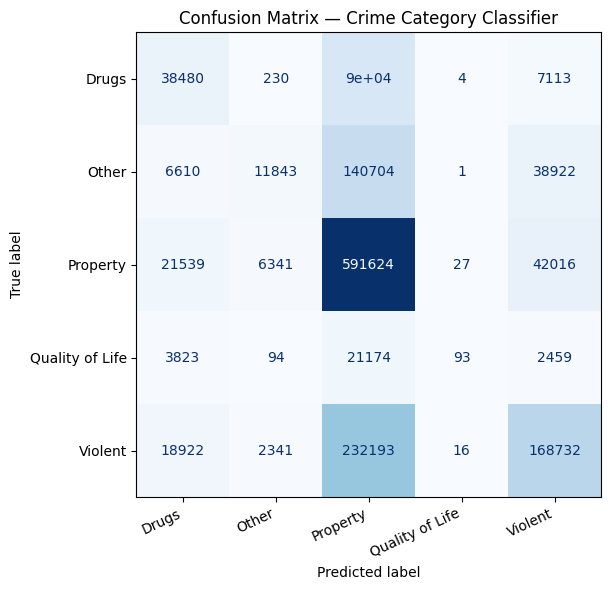

In [137]:
# Train XGBoost classifier (Model A)
clf_a = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
clf_a.fit(X_tr, y_tr,
          eval_set=[(X_te, y_te)], verbose=False)

y_pred_a = clf_a.predict(X_te)
print("\nCrime Category Classification Report")
print(classification_report(y_te, y_pred_a, target_names=le_a.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_te, y_pred_a)
ConfusionMatrixDisplay(cm, display_labels=le_a.classes_).plot(ax=ax, cmap="Blues",
    colorbar=False)
ax.set_title("Confusion Matrix — Crime Category Classifier")
plt.xticks(rotation=25, ha="right"); 
plt.tight_layout(); 
plt.show()


Comparing with Random Forest model 

RF subsampled to 500,000 rows for tractability

Random Forest — Crime Category Classification Report
                 precision    recall  f1-score   support

          Drugs       0.25      0.58      0.35    136302
          Other       0.28      0.39      0.32    198080
       Property       0.64      0.42      0.50    661547
Quality of Life       0.06      0.38      0.10     27643
        Violent       0.66      0.38      0.48    422204

       accuracy                           0.41   1445776
      macro avg       0.38      0.43      0.35   1445776
   weighted avg       0.55      0.41      0.45   1445776



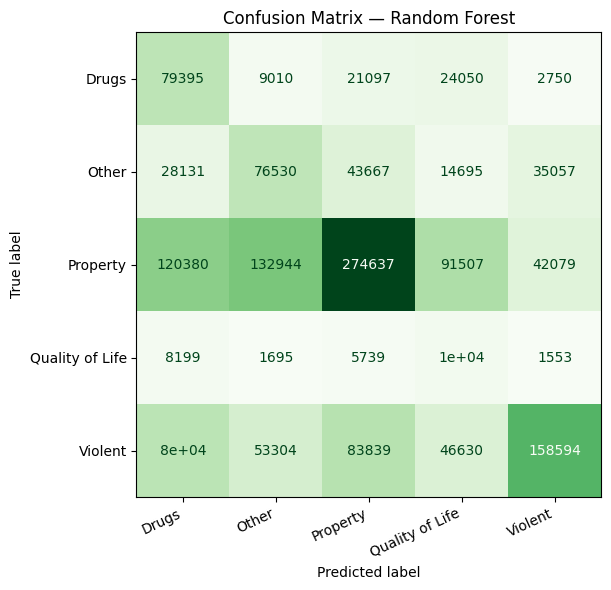

In [135]:
from sklearn.ensemble import RandomForestClassifier

MAX_RF_ROWS = 500_000
if len(X_tr) > MAX_RF_ROWS:
    idx      = np.random.RandomState(RANDOM_STATE).choice(
                    len(X_tr), MAX_RF_ROWS, replace=False)
    X_tr_rf  = X_tr.iloc[idx] if hasattr(X_tr, "iloc") else X_tr[idx]
    y_tr_rf  = y_tr.iloc[idx] if hasattr(y_tr, "iloc") else y_tr[idx]
    print(f"RF subsampled to {MAX_RF_ROWS:,} rows for tractability")
else:
    X_tr_rf, y_tr_rf = X_tr, y_tr

clf_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
clf_rf.fit(X_tr_rf, y_tr_rf)

y_pred_rf = clf_rf.predict(X_te)
print("\nRandom Forest — Crime Category Classification Report")
print(classification_report(y_te, y_pred_rf, target_names=le_a.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
cm_rf = confusion_matrix(y_te, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le_a.classes_).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Confusion Matrix — Random Forest")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


Model Comparison — Crime Category Classification
               Accuracy  F1 Macro  F1 Weighted
Model                                         
XGBoost          0.5608    0.3264       0.5033
Random Forest    0.4147    0.3511       0.4498


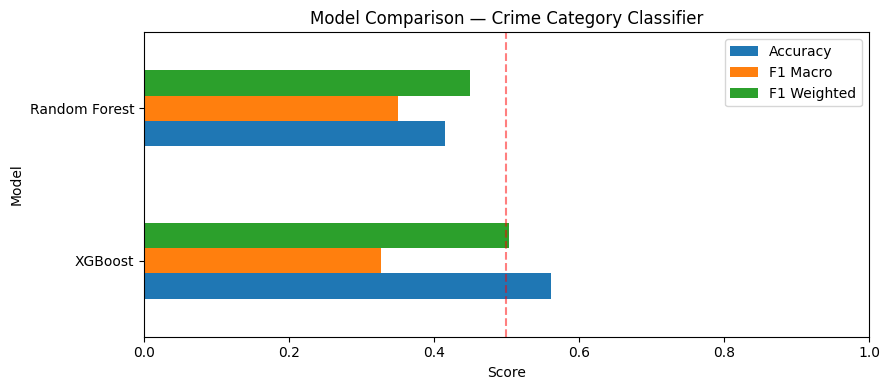

In [138]:
from sklearn.metrics import accuracy_score, f1_score

comparison_df = pd.DataFrame([
    {
        "Model"       : "XGBoost",
        "Accuracy"    : accuracy_score(y_te, y_pred_a),
        "F1 Macro"    : f1_score(y_te, y_pred_a, average="macro"),
        "F1 Weighted" : f1_score(y_te, y_pred_a, average="weighted")
    },
    
    {
        "Model"       : "Random Forest",
        "Accuracy"    : accuracy_score(y_te, y_pred_rf),
        "F1 Macro"    : f1_score(y_te, y_pred_rf, average="macro"),
        "F1 Weighted" : f1_score(y_te, y_pred_rf, average="weighted")
    },
]).set_index("Model").round(4)

print("\nModel Comparison — Crime Category Classification")
print(comparison_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
comparison_df.plot.barh(ax=ax, xlim=(0, 1))
ax.set_title("Model Comparison — Crime Category Classifier")
ax.set_xlabel("Score")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 6B  Arrest Prediction
ARR_FEATURES = ["hour", "dow", "month", "is_weekend", "Community Area",
                "District", "loc_bucket", "Domestic", "crime_category"]
TARGET_B = "Arrest"

arr_df = df_temporal[ARR_FEATURES + [TARGET_B]].dropna().copy()
arr_df["Domestic"] = arr_df["Domestic"].astype(int)
arr_df[TARGET_B]   = arr_df[TARGET_B].astype(int)

#  1. Cyclic encoding for time features 
for col, period in [("hour", 24), ("dow", 7), ("month", 12)]:
    arr_df[f"{col}_sin"] = np.sin(2 * np.pi * arr_df[col] / period)
    arr_df[f"{col}_cos"] = np.cos(2 * np.pi * arr_df[col] / period)
arr_df.drop(columns=["hour", "dow", "month"], inplace=True)

#2. Label-encode crime_category
le_crime = LabelEncoder()
arr_df["crime_category"] = le_crime.fit_transform(
    arr_df["crime_category"].astype(str))

# 3. Feature list 
NOMINAL_COLS_B   = ["Community Area", "District", "loc_bucket"]
FINAL_FEATURES_B = ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
                    "month_sin", "month_cos", "is_weekend", "Domestic",
                    "crime_category"] + NOMINAL_COLS_B

X_b = arr_df[FINAL_FEATURES_B].copy()
y_b = arr_df[TARGET_B]

#  4. Split before target encoding 
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_STATE)

X_tr_b = X_tr_b.reset_index(drop=True)
X_te_b = X_te_b.reset_index(drop=True)
y_tr_b_series = pd.Series(y_tr_b.values)  
#  5. Target encode nominals 
def target_encode(train_df, test_df, col, target, noise_std=0.01):
    tmp = train_df[[col]].copy()
    tmp["__target__"] = target.values
    means       = tmp.groupby(col)["__target__"].mean()
    global_mean = target.mean()

    train_enc = train_df[col].map(means).fillna(global_mean)
    train_enc = train_enc + np.random.normal(0, noise_std, size=len(train_enc))
    test_enc  = test_df[col].map(means).fillna(global_mean)
    return train_enc.values, test_enc.values

for col in NOMINAL_COLS_B:
    X_tr_b[col], X_te_b[col] = target_encode(
        X_tr_b, X_te_b, col, y_tr_b_series)

print(f"Features ({X_tr_b.shape[1]}): {list(X_tr_b.columns)}")

# 6. LightGBM 
clf_b = lgb.LGBMClassifier(
    n_estimators=400,
    num_leaves=63,
    learning_rate=0.06,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
clf_b.fit(
    X_tr_b, y_tr_b,
    eval_set=[(X_te_b, y_te_b)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(50)]
)

y_pred_b = clf_b.predict(X_te_b)
y_prob_b = clf_b.predict_proba(X_te_b)[:, 1]

print("\n Arrest Prediction Report")
print(classification_report(y_te_b, y_pred_b, target_names=["No Arrest", "Arrest"]))
print(f"ROC-AUC       : {roc_auc_score(y_te_b, y_prob_b):.4f}")






print(f"Avg Precision : {average_precision_score(y_te_b, y_prob_b):.4f}")

Features (12): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'Domestic', 'crime_category', 'Community Area', 'District', 'loc_bucket']
[50]	valid_0's binary_logloss: 0.459393
[100]	valid_0's binary_logloss: 0.44574
[150]	valid_0's binary_logloss: 0.44474
[200]	valid_0's binary_logloss: 0.444514
[250]	valid_0's binary_logloss: 0.444362
[300]	valid_0's binary_logloss: 0.444217

 Arrest Prediction Report
              precision    recall  f1-score   support

   No Arrest       0.87      0.91      0.89   1074179
      Arrest       0.69      0.59      0.64    371597

    accuracy                           0.83   1445776
   macro avg       0.78      0.75      0.76   1445776
weighted avg       0.82      0.83      0.82   1445776

ROC-AUC       : 0.8301
Avg Precision : 0.7506


RF subsampled to 500,000 rows for tractability

Random Forest — Arrest Prediction Report
              precision    recall  f1-score   support

   No Arrest       0.86      0.94      0.90   1074179
      Arrest       0.76      0.56      0.64    371597

    accuracy                           0.84   1445776
   macro avg       0.81      0.75      0.77   1445776
weighted avg       0.83      0.84      0.83   1445776

ROC-AUC       : 0.8256
Avg Precision : 0.7446


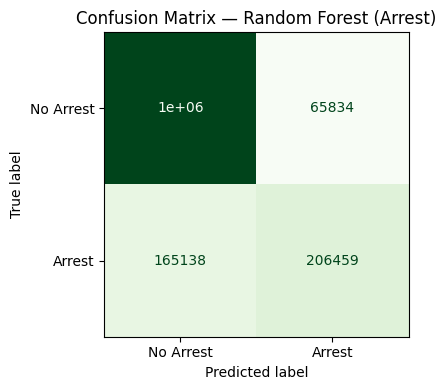

In [139]:
from sklearn.ensemble import RandomForestClassifier

MAX_RF_ROWS = 500_000
if len(X_tr_b) > MAX_RF_ROWS:
    idx       = np.random.RandomState(RANDOM_STATE).choice(
                    len(X_tr_b), MAX_RF_ROWS, replace=False)
    X_tr_b_rf = X_tr_b.iloc[idx]
    y_tr_b_rf = y_tr_b.iloc[idx] if hasattr(y_tr_b, "iloc") else y_tr_b[idx]
    print(f"RF subsampled to {MAX_RF_ROWS:,} rows for tractability")
else:
    X_tr_b_rf, y_tr_b_rf = X_tr_b, y_tr_b

clf_rf_b = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
clf_rf_b.fit(X_tr_b_rf, y_tr_b_rf)

y_pred_rf_b = clf_rf_b.predict(X_te_b)
y_prob_rf_b = clf_rf_b.predict_proba(X_te_b)[:, 1]

print("\nRandom Forest — Arrest Prediction Report")
print(classification_report(y_te_b, y_pred_rf_b, target_names=["No Arrest", "Arrest"]))
print(f"ROC-AUC       : {roc_auc_score(y_te_b, y_prob_rf_b):.4f}")
print(f"Avg Precision : {average_precision_score(y_te_b, y_prob_rf_b):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
cm_rf_b = confusion_matrix(y_te_b, y_pred_rf_b)
ConfusionMatrixDisplay(cm_rf_b, display_labels=["No Arrest", "Arrest"]).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Confusion Matrix — Random Forest (Arrest)")
plt.tight_layout()
plt.show()

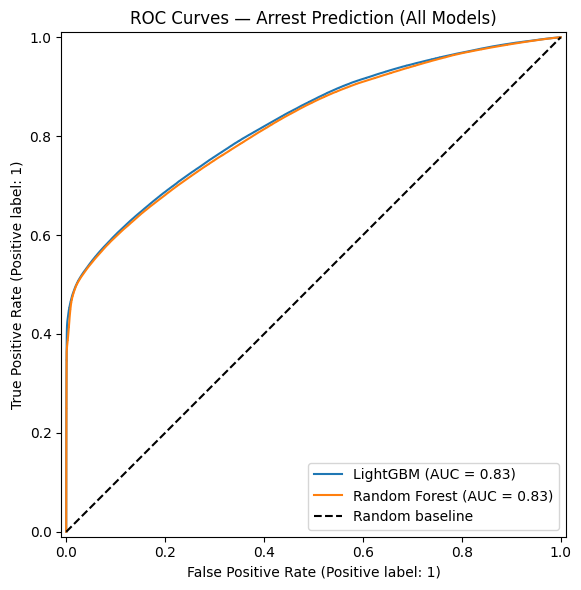


Model Comparison — Arrest Prediction (Binary)
               Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Avg Precision
Model                                                                 
LightGBM         0.8273    0.7623       0.8227   0.8301         0.7506
Random Forest    0.8402    0.7693       0.8315   0.8256         0.7446


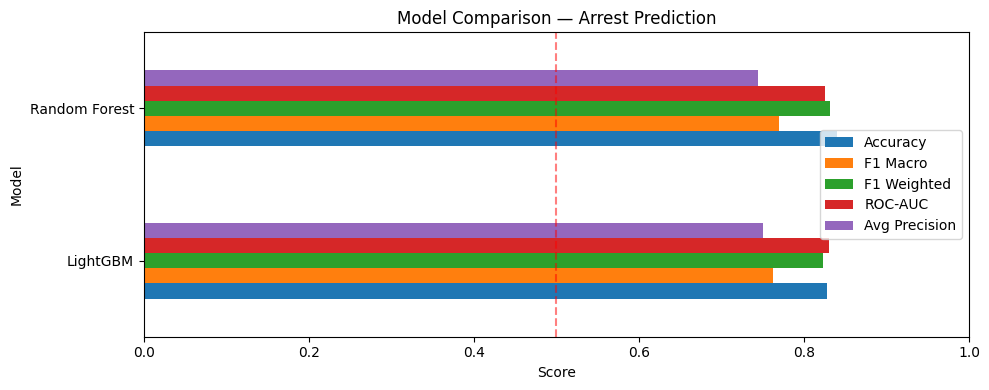

In [140]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [
    ("LightGBM",           y_prob_b),
    ("Random Forest",      y_prob_rf_b),
]:
    RocCurveDisplay.from_predictions(
        y_te_b, y_prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_title("ROC Curves — Arrest Prediction (All Models)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

from sklearn.metrics import accuracy_score, f1_score

comparison_b = pd.DataFrame([
    {
        "Model"        : "LightGBM",
        "Accuracy"     : accuracy_score(y_te_b, y_pred_b),
        "F1 Macro"     : f1_score(y_te_b, y_pred_b,     average="macro"),
        "F1 Weighted"  : f1_score(y_te_b, y_pred_b,     average="weighted"),
        "ROC-AUC"      : roc_auc_score(y_te_b, y_prob_b),
        "Avg Precision": average_precision_score(y_te_b, y_prob_b)
    },
    
    {
        "Model"        : "Random Forest",
        "Accuracy"     : accuracy_score(y_te_b, y_pred_rf_b),
        "F1 Macro"     : f1_score(y_te_b, y_pred_rf_b,  average="macro"),
        "F1 Weighted"  : f1_score(y_te_b, y_pred_rf_b,  average="weighted"),
        "ROC-AUC"      : roc_auc_score(y_te_b, y_prob_rf_b),
        "Avg Precision": average_precision_score(y_te_b, y_prob_rf_b)
    },
    
]).set_index("Model").round(4)

print("\nModel Comparison — Arrest Prediction (Binary)")
print(comparison_b.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
comparison_b.plot.barh(ax=ax, xlim=(0, 1))
ax.set_title("Model Comparison — Arrest Prediction")
ax.set_xlabel("Score")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Crime Count Regression(time series) Model-C

Regression Results | MAE: 0.29  RMSE: 0.51  MAPE: 20.6%


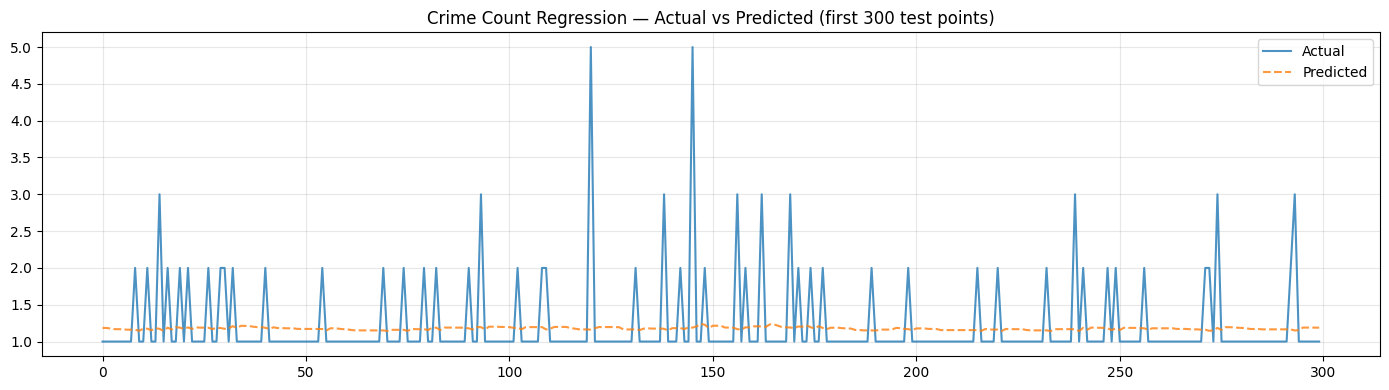

In [114]:
# 6C  Crime Count Regression (Time-Series) 
ts = (df_temporal.groupby(["Date","District"])
      .size().reset_index(name="count"))
ts["date"] = pd.to_datetime(ts["Date"].dt.date)
ts = ts.sort_values(["District","Date"]).reset_index(drop=True)

# Lag features
for lag in [1, 7, 14, 28]:
    ts[f"lag_{lag}"] = ts.groupby("District")["count"].shift(lag)

ts["rolling_7"]  = ts.groupby("District")["count"].transform(lambda x: x.shift(1).rolling(7).mean())
ts["rolling_28"] = ts.groupby("District")["count"].transform(lambda x: x.shift(1).rolling(28).mean())
ts["dow"]        = ts["Date"].dt.dayofweek
ts["month"]      = ts["Date"].dt.month
ts["year"]       = ts["Date"].dt.year

ts_clean = ts.dropna()
reg_features = [f"lag_{l}" for l in [1,7,14,28]] + ["rolling_7","rolling_28","dow","month","year"]

X_r = ts_clean[reg_features]
y_r = ts_clean["count"]

split_idx = int(len(X_r) * 0.8)
X_tr_r, X_te_r = X_r.iloc[:split_idx], X_r.iloc[split_idx:]
y_tr_r, y_te_r = y_r.iloc[:split_idx], y_r.iloc[split_idx:]

reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08,
                        subsample=0.8, random_state=RANDOM_STATE, n_jobs=-1)
reg.fit(X_tr_r, y_tr_r)
y_hat_r = reg.predict(X_te_r)

mae  = mean_absolute_error(y_te_r, y_hat_r)
rmse = np.sqrt(mean_squared_error(y_te_r, y_hat_r))
mape = np.mean(np.abs((y_te_r - y_hat_r) / (y_te_r + 1e-6))) * 100

print(f"Regression Results | MAE: {mae:.2f}  RMSE: {rmse:.2f}  MAPE: {mape:.1f}%")

# Plot actuals vs predicted
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te_r.values[:300], label="Actual", alpha=0.8, lw=1.5)
ax.plot(y_hat_r[:300],       label="Predicted", alpha=0.8, lw=1.5, ls="--")
ax.set_title("Crime Count Regression — Actual vs Predicted (first 300 test points)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


RF subsampled to 500,000 / 5,350,103 rows
Random Forest | MAE: 0.29  RMSE: 0.51  MAPE: 20.6%


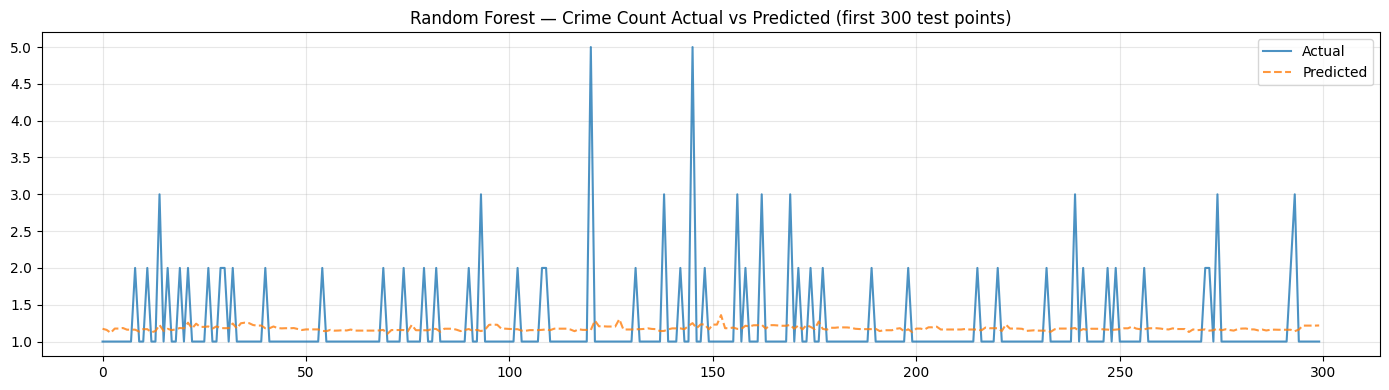

In [141]:
# MODEL C2 — Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

MAX_RF_ROWS = 500_000
if len(X_tr_r) > MAX_RF_ROWS:
    idx       = np.random.RandomState(RANDOM_STATE).choice(
                    len(X_tr_r), MAX_RF_ROWS, replace=False)
    X_tr_r_rf = X_tr_r.iloc[idx]
    y_tr_r_rf = y_tr_r.iloc[idx]
    print(f"RF subsampled to {MAX_RF_ROWS:,} / {len(X_tr_r):,} rows")
else:
    X_tr_r_rf, y_tr_r_rf = X_tr_r, y_tr_r

reg_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
reg_rf.fit(X_tr_r_rf, y_tr_r_rf)
y_hat_rf_r = reg_rf.predict(X_te_r)

mae_rf  = mean_absolute_error(y_te_r, y_hat_rf_r)
rmse_rf = np.sqrt(mean_squared_error(y_te_r, y_hat_rf_r))
mape_rf = np.mean(np.abs((y_te_r - y_hat_rf_r) / (y_te_r + 1e-6))) * 100
print(f"Random Forest | MAE: {mae_rf:.2f}  RMSE: {rmse_rf:.2f}  MAPE: {mape_rf:.1f}%")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te_r.values[:300], label="Actual",    alpha=0.8, lw=1.5)
ax.plot(y_hat_rf_r[:300],    label="Predicted", alpha=0.8, lw=1.5, ls="--")
ax.set_title("Random Forest — Crime Count Actual vs Predicted (first 300 test points)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

[50]	valid_0's l2: 0.263088
[100]	valid_0's l2: 0.26307
LightGBM | MAE: 0.29  RMSE: 0.51  MAPE: 20.6%


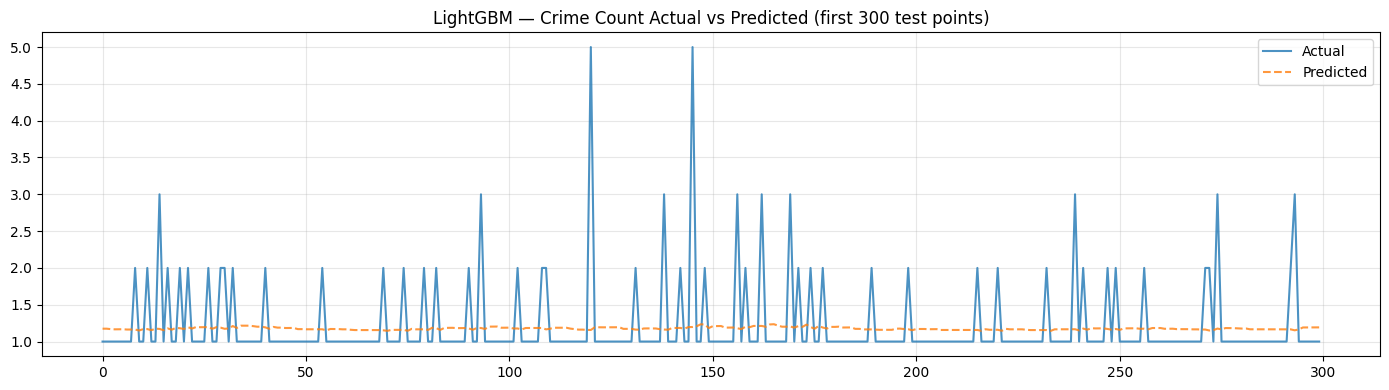

In [ ]:
# MODEL C3 — LightGBM Regressor 
import lightgbm as lgb

reg_lgb = lgb.LGBMRegressor(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
reg_lgb.fit(
    X_tr_r, y_tr_r,
    eval_set=[(X_te_r, y_te_r)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(50)]
)
y_hat_lgb_r = reg_lgb.predict(X_te_r)

mae_lgb  = mean_absolute_error(y_te_r, y_hat_lgb_r)
rmse_lgb = np.sqrt(mean_squared_error(y_te_r, y_hat_lgb_r))
mape_lgb = np.mean(np.abs((y_te_r - y_hat_lgb_r) / (y_te_r + 1e-6))) * 100
print(f"LightGBM | MAE: {mae_lgb:.2f}  RMSE: {rmse_lgb:.2f}  MAPE: {mape_lgb:.1f}%")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te_r.values[:300], label="Actual",    alpha=0.8, lw=1.5)
ax.plot(y_hat_lgb_r[:300],   label="Predicted", alpha=0.8, lw=1.5, ls="--")
ax.set_title("LightGBM — Crime Count Actual vs Predicted (first 300 test points)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Phase 7 — Feature Importance & SHAP Interpretation

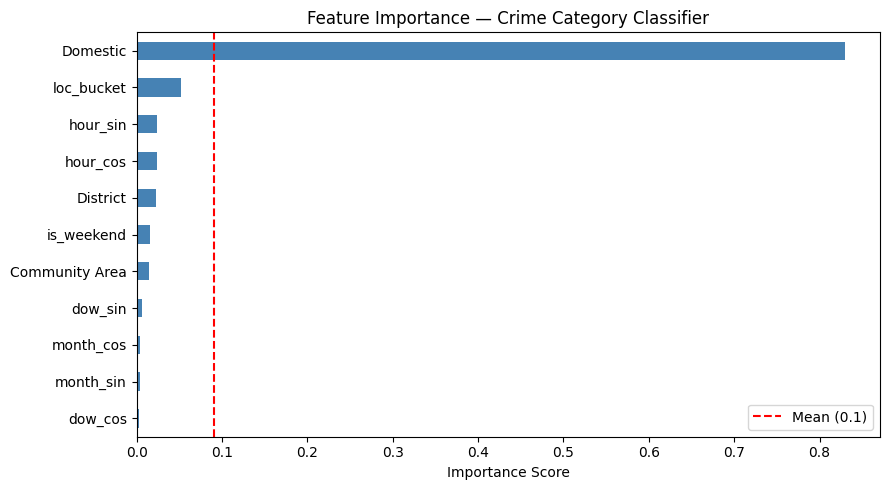


Top 5 most important features:
District      0.022717
hour_cos      0.023490
hour_sin      0.023947
loc_bucket    0.052445
Domestic      0.829253


In [ ]:
#  Feature Importance — Crime Category Classifier (Model A) 
feature_names = X_tr.columns.tolist() 
importances = pd.Series(
    clf_a.feature_importances_,
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_title("Feature Importance — Crime Category Classifier")
ax.set_xlabel("Importance Score")
ax.axvline(importances.mean(), color="red", linestyle="--",
           label=f"Mean ({importances.mean():.1f})")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.tail(5).to_string())

SHAP values shape : (5000, 11, 5)
Feature names count: 11


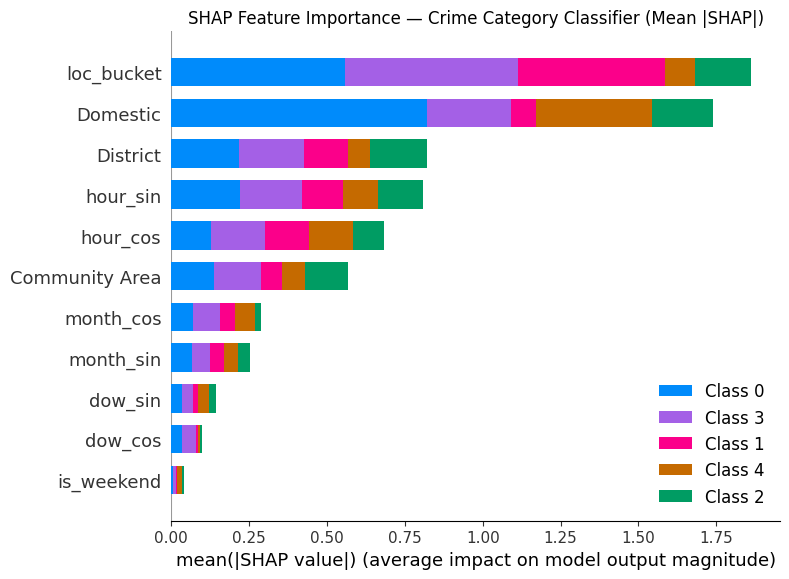

In [ ]:
#  SHAP Summary Plot (Model A — Crime Category)

sample_size = min(5000, len(X_te))
X_shap = X_te.sample(sample_size, random_state=RANDOM_STATE)

feature_names_a = X_te.columns.tolist()   

explainer_a = shap.TreeExplainer(clf_a)
shap_vals   = explainer_a.shap_values(X_shap)

if isinstance(shap_vals, list):
    mean_shap = np.mean([np.abs(sv) for sv in shap_vals], axis=0)
    shap_vals_plot = mean_shap
else:
    shap_vals_plot = shap_vals

print(f"SHAP values shape : {shap_vals_plot.shape}")     
print(f"Feature names count: {len(feature_names_a)}")     

shap.summary_plot(
    shap_vals_plot,
    X_shap,
    feature_names=feature_names_a,  
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — Crime Category Classifier (Mean |SHAP|)")
plt.tight_layout()
plt.show()

SHAP values shape : (3000, 12)
Feature names count: 12


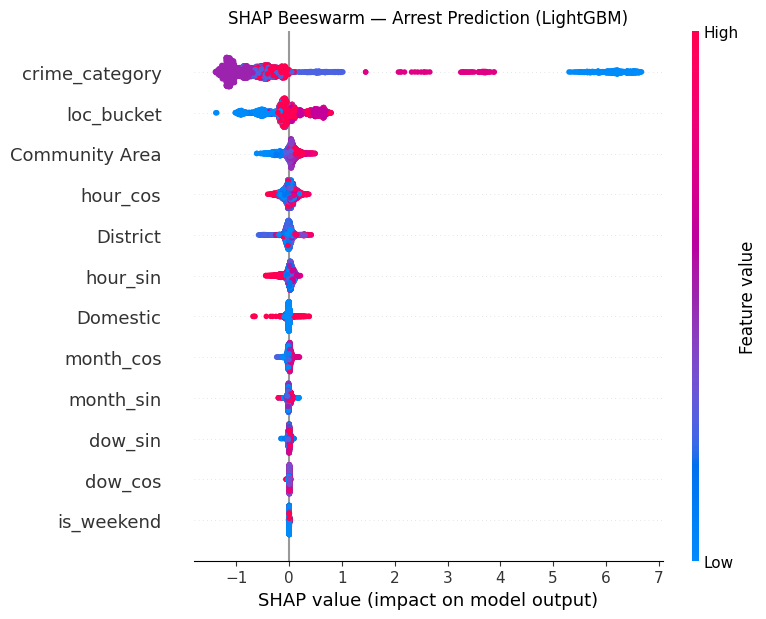

In [ ]:
# SHAP Beeswarm — Arrest Prediction (Model B) 

X_shap_b = X_te_b.sample(min(3000, len(X_te_b)), random_state=RANDOM_STATE)

explainer_b = shap.TreeExplainer(clf_b)
shap_vals_b = explainer_b.shap_values(X_shap_b)

# LightGBM binary returns list of 2 arrays [class_0, class_1] → take class_1
if isinstance(shap_vals_b, list):
    shap_vals_b = shap_vals_b[1]

feature_names_b = X_te_b.columns.tolist()  

print(f"SHAP values shape : {shap_vals_b.shape}")        
print(f"Feature names count: {len(feature_names_b)}")    

shap.summary_plot(
    shap_vals_b,
    X_shap_b,
    feature_names=feature_names_b,   
    show=False,
    max_display=12
)
plt.title("SHAP Beeswarm — Arrest Prediction (LightGBM)")
plt.tight_layout()
plt.show()

In [123]:
hours = np.arange(0, 24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)


In [ ]:
# Built synthetic grid of feature values for PDP (varying hour, keeping others at median)
X_pdp = pd.DataFrame(
    np.tile(X_te_b.median().values, (24, 1)),
    columns=X_te_b.columns
)
X_pdp["hour_sin"] = hour_sin
X_pdp["hour_cos"] = hour_cos


In [125]:
# Predict arrest probability for each hour
arrest_probs = clf_b.predict_proba(X_pdp)[:, 1]

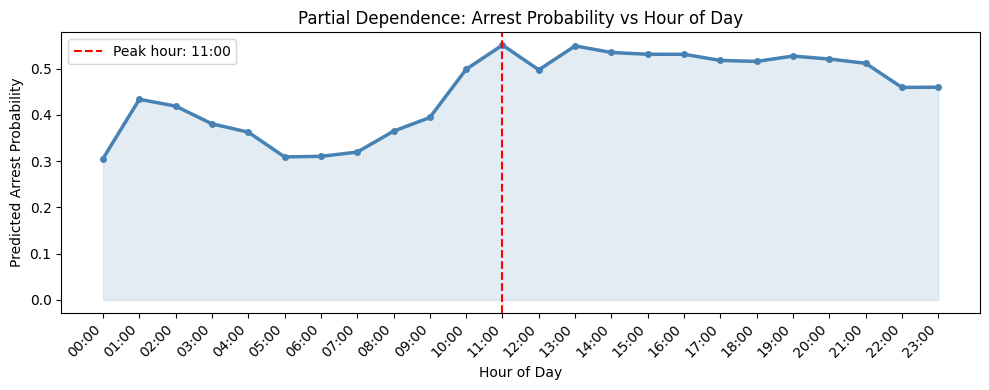

Highest arrest probability at: 11:00  (0.551)
Lowest  arrest probability at: 00:00  (0.306)


In [ ]:
# Plot 
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, arrest_probs, lw=2.5, color="steelblue", marker="o", ms=4)
ax.fill_between(hours, arrest_probs, alpha=0.15, color="steelblue")

ax.set_xticks(hours)
ax.set_xticklabels([f"{h:02d}:00" for h in hours], rotation=45, ha="right")
ax.set_title("Partial Dependence: Arrest Probability vs Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Predicted Arrest Probability")
ax.axvline(arrest_probs.argmax(), color="red", linestyle="--",
           label=f"Peak hour: {arrest_probs.argmax():02d}:00")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Highest arrest probability at: {arrest_probs.argmax():02d}:00  "
      f"({arrest_probs.max():.3f})")
print(f"Lowest  arrest probability at: {arrest_probs.argmin():02d}:00  "
      f"({arrest_probs.min():.3f})")


# Summary & Prescriptive Insights

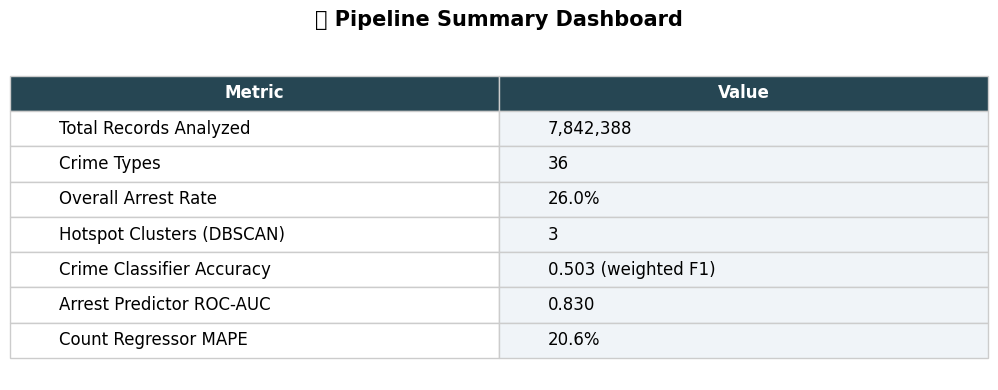

In [145]:
# Dashboard: key metrics 
metrics = {
    "Total Records Analyzed": f"{len(df_temporal):,}",
    "Crime Types": f"{df_temporal['Primary Type'].nunique()}",
    "Overall Arrest Rate": f"{df_temporal['Arrest'].mean()*100:.1f}%",
    "Hotspot Clusters (DBSCAN)": f"{n_clusters}",
    "Crime Classifier Accuracy": f"{f1_score(y_te, y_pred_a, average='weighted'):.3f} (weighted F1)",
    "Arrest Predictor ROC-AUC": f"{roc_auc_score(y_te_b, y_prob_b):.3f}",
    "Count Regressor MAPE": f"{mape:.1f}%",
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
rows = [[k, v] for k, v in metrics.items()]
tbl = ax.table(cellText=rows, colLabels=["Metric","Value"],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(12)
tbl.scale(1.2, 2.0)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0: cell.set_facecolor("#264653"); cell.set_text_props(color="white", fontweight="bold")
    elif c == 1: cell.set_facecolor("#f0f4f8")
ax.set_title("📋 Pipeline Summary Dashboard", fontsize=15, pad=20, fontweight="bold")
plt.tight_layout(); plt.show()
